In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
tf.__version__

'2.3.0'

In [7]:
mnist=tf.keras.datasets.mnist #28*28 image data set

(x_train,y_train),(x_test,y_test)=mnist.load_data()

x_train=tf.keras.utils.normalize(x_train)#normalize between 0 and 1
x_test=tf.keras.utils.normalize(x_test)

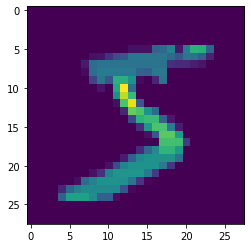

In [8]:
plt.imshow(x_train[0])
plt.show()

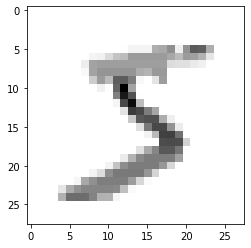

In [9]:
plt.imshow(x_train[0],plt.cm.binary)
plt.show()

In [16]:
#architecture
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128,activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(128,activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(10,activation=tf.nn.softmax))

model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
             )

model.fit(x_train,y_train,epochs=3)

Epoch 1/3
1875/1875 [==============================] - 2s 854us/step - loss: 0.2574 - accuracy: 0.9222
Epoch 2/3
1875/1875 [==============================] - 2s 916us/step - loss: 0.1076 - accuracy: 0.9670
Epoch 3/3
1875/1875 [==============================] - 2s 852us/step - loss: 0.0740 - accuracy: 0.9773


In [17]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_4 (Flatten)          (32, 784)                 0         
_________________________________________________________________
dense_12 (Dense)             (32, 128)                 100480    
_________________________________________________________________
dense_13 (Dense)             (32, 128)                 16512     
_________________________________________________________________
dense_14 (Dense)             (32, 10)                  1290      
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
_________________________________________________________________


In [18]:
val_loss,val_acc=model.evaluate(x_test,y_test)
print(val_loss,val_acc)

313/313 [==============================] - 0s 503us/step - loss: 0.0878 - accuracy: 0.9719
0.08778452128171921 0.9718999862670898


In [19]:
model.save('mnist_1st.model')

Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
INFO:tensorflow:Assets written to: mnist_1st.model/assets


In [20]:
new_model=tf.keras.models.load_model('mnist_1st.model')

In [26]:
prediction=new_model.predict([x_test])
prediction

array([[1.83713578e-08, 6.19653576e-07, 3.16412043e-05, ...,
        9.99962091e-01, 2.73333550e-10, 2.20347090e-07],
       [6.15261939e-08, 1.53924979e-04, 9.99781430e-01, ...,
        1.94517128e-07, 1.07927581e-05, 2.13928632e-11],
       [1.70602974e-07, 9.97940600e-01, 9.77720993e-06, ...,
        1.77088857e-03, 3.47630339e-05, 3.33386788e-06],
       ...,
       [4.38528680e-09, 2.92103323e-07, 1.84058582e-08, ...,
        1.02370162e-03, 1.18405751e-05, 1.04468250e-04],
       [6.62904354e-09, 1.25498467e-09, 8.50849113e-11, ...,
        1.09286205e-10, 1.78127066e-05, 4.82263722e-08],
       [6.60355255e-08, 9.02420716e-09, 1.04719241e-07, ...,
        1.22162849e-10, 5.23809689e-08, 2.29743291e-09]], dtype=float32)

In [25]:
print(np.argmax(prediction[0]))

7


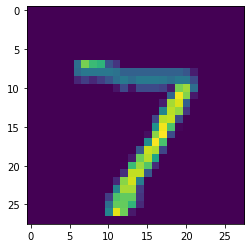

In [28]:
plt.imshow(x_test[0])